# Ayudantía 7: Analisis de datos geoespaciales

08 de Mayo 2025

Juan Pablo Tapia

jp.tapia@uc.cl

## Contenido

### **1. Sistemas de Información Geográfica (GIS)**

Un Sistema de Información Geográfica (GIS) es una combinación de software, hardware y datos geográficos que permite capturar, almacenar, analizar y visualizar información referida a lugares del mundo real.

¿Para qué sirve un GIS?
* Planificación urbana.

* Gestión ambiental.

* Ingeniería de transporte.

* Infraestructura pública.

¿Cómo funciona?

Un GIS asocia información alfanumérica (por ejemplo, población o nivel socioeconómico) a entidades gráficas en un mapa (como polígonos o puntos)

### **2. Tipos de Datos y Geometrías en GIS**

Geometrías principales:
* Punto: Representa ubicaciones exactas (ej: estaciones de metro).

* Línea: Representa conexiones (ej: rutas de buses o líneas de metro).

* Polígono: Representa áreas cerradas (ej: comunas o distritos).

Formatos comunes: El formato más usado es ESRI Shapefile (.shp), que está compuesto por varios archivos:

* .shp: contiene la geometría (puntos, líneas o polígonos).

* .dbf: contiene los datos alfanuméricos asociados.

* .shx: índice para relacionar geometrías con datos.

* .prj: contiene el sistema de coordenadas usado.

### **3. Sistemas de Coordenadas y Proyecciones**

Los datos espaciales deben tener un sistema de referencia común para que los análisis sean válidos.

EPSG:4326 (Latitud/Longitud, como Google Maps)

EPSG:32719 (UTM Zona 19S, usado para Santiago)

El archivo .prj indica qué sistema de coordenadas usa el shapefile. Si no está presente, hay que especificarlo manualmente.



### **4. Análisis Geoespacial con Python**

Librerías principales:
* pandas: para trabajar con datos tabulares (como Excel).

* geopandas: extiende pandas para incluir datos geográficos.

```
import pandas as pd
import geopandas as gpd
```

Con geopandas, se pueden leer shapefiles y trabajar con geometrías como si fueran columnas de un DataFrame.

### **5. Operaciones Espaciales**


Estas operaciones permiten relacionar objetos espaciales entre sí:

* Unión Espacial (Spatial Join): Combina datos de dos capas basándose en intersección o proximidad.

```
gpd.sjoin(distritos, estaciones, how='left', predicate='intersects')
```

* Intersección: Crea una nueva capa con los elementos comunes entre dos geometrías.

```
distritos_interseccion = distritos.overlay(areas_verdes, how='intersection')
```

* Buffers: Crea un área de influencia alrededor de un punto, línea o polígono.

```
estaciones['buffer_1000m'] = estaciones.geometry.buffer(1000)
```

### **6. Visualización Geoespacial**


Con geopandas, se pueden generar mapas fácilmente:

```
distritos.plot(column='clasificacion', cmap='RdYlGn', legend=True)
```

Esto permite representar visualmente variables como:

* Nivel socioeconómico.

* Densidad poblacional.

* Accesibilidad al transporte.

### **7.  Metodología del Trabajo con Datos Geoespaciales**


**Paso 1: Preparación del Entorno**

Importar las librerías necesarias.

```
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
```

**Paso 2: Cargar los Datos**

Leer shapefiles y explorar los atributos.

```
gdf = gpd.read_file("ruta.shp")
gdf.head()
```

**Paso 3: Procesamiento de Datos**

Transformar y limpiar los datos, calcular métricas.

**Paso 4: Operaciones Espaciales**

Realizar análisis con buffers, joins o intersecciones.

**Paso 5: Visualización**

Generar mapas para mostrar los resultados con claridad.

## Ejercicio Formativo 1 Capítulo 4

Importar las librerias necesarias.

In [94]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

Cargar datos.

In [95]:
!unzip Data.zip

Archive:  Data.zip
replace Data/Areas Urbanas/areas_urbanas.dbf? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


### Misión 1

Leer archivos .shp

In [96]:
distritos_shp = "Data/Distritos Censales/Distritos Censales RM.shp"
areas_urbanas_shp = "Data/Areas Urbanas/areas_urbanas.shp"

distritos = gpd.read_file(distritos_shp)
areas_urbanas = gpd.read_file(areas_urbanas_shp)

display(distritos.head())
display(distritos.info())

display(areas_urbanas.head())
display(areas_urbanas.info())

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346775.511 6299463.724, 346788.392 6..."
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345880.28 6299633.958, 345961.61 629..."
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345546.017 6299748.84, 345650.511 62..."
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((344856.32 6298892.632, 345672.277 62..."
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((343856.526 6298225.435, 344041.982 6..."


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 449 entries, 0 to 448
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   NOM_REG    449 non-null    object  
 1   COD_PROV   449 non-null    object  
 2   NOM_PROV   449 non-null    object  
 3   COD_COM    449 non-null    object  
 4   NOM_COM    449 non-null    object  
 5   NOM_DIS    449 non-null    object  
 6   CODIGO     449 non-null    float64 
 7   E          449 non-null    float64 
 8   D          449 non-null    float64 
 9   C3         449 non-null    float64 
 10  C2         449 non-null    float64 
 11  ABC1       449 non-null    float64 
 12  ADIMARK_T  449 non-null    float64 
 13  Area       449 non-null    float64 
 14  Densidad   449 non-null    float64 
 15  1_UF_M2    449 non-null    float64 
 16  geometry   449 non-null    geometry
dtypes: float64(10), geometry(1), object(6)
memory usage: 59.8+ KB


None

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
0,Chiguayante,Ciudad,29855.998337,1.038076e+07,"POLYGON ((140044.634 5911024.284, 140051.361 5..."
1,Lota,Ciudad,14233.349738,5.262642e+06,"POLYGON ((131359.666 5889462.902, 131475.343 5..."
2,Coronel,Ciudad,41577.791832,1.551685e+07,"POLYGON ((127278.44 5896965.436, 127411.675 58..."
3,San Rosendo,Ciudad,6499.369423,1.534402e+06,"POLYGON ((168583.83 5870293.97, 168725.579 587..."
4,Concepción,Ciudad,82986.894378,3.454227e+07,"POLYGON ((133504.854 5919782.212, 136052.58 59..."


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   NOMBRE      400 non-null    object  
 1   TIPO_AREA   400 non-null    object  
 2   SHAPE_Leng  400 non-null    float64 
 3   SHAPE_Area  400 non-null    float64 
 4   geometry    400 non-null    geometry
dtypes: float64(2), geometry(1), object(2)
memory usage: 15.8+ KB


None

Funciones:
- **gpd.read_file()**: Esta función carga los datos geoespaciales desde los archivos shapefile (.shp). Los datos incluyen tanto información tabular como la geometría.
- **head()**: Nos muestran los primeros registros de ambos DataFrames, lo que nos permite entender las columnas disponibles y el tipo de datos.
- **info()**: Proporcionan un resumen de las columnas, el tipo de datos de cada una, y si existen valores nulos. Esto es útil para planificar las operaciones que haremos posteriormente con estos datos.

Visualizar distritos.

<Axes: >

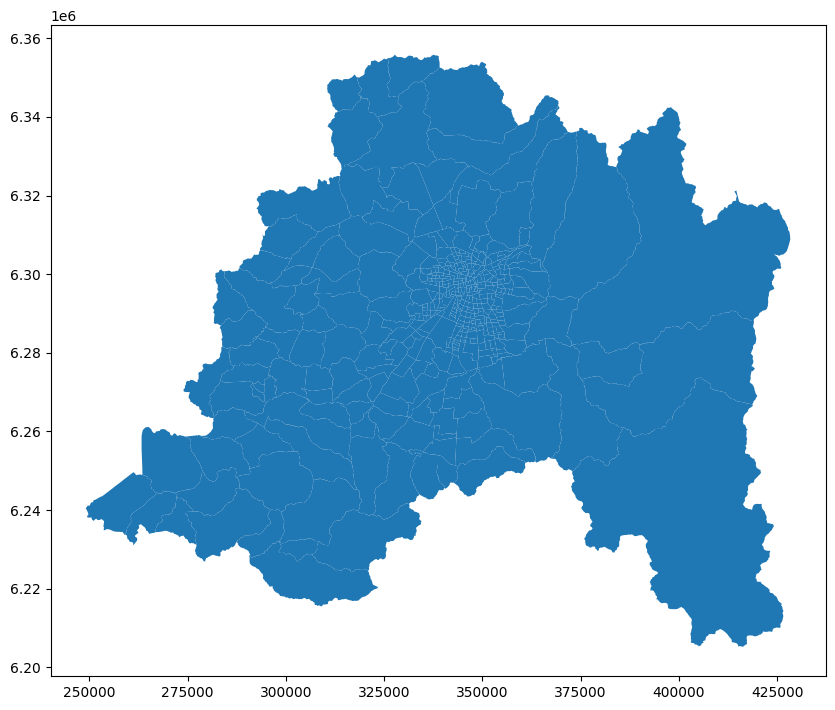

In [97]:
distritos.plot(figsize = (10,10))

Graficar áreas urbanas de Santiago

<Axes: >

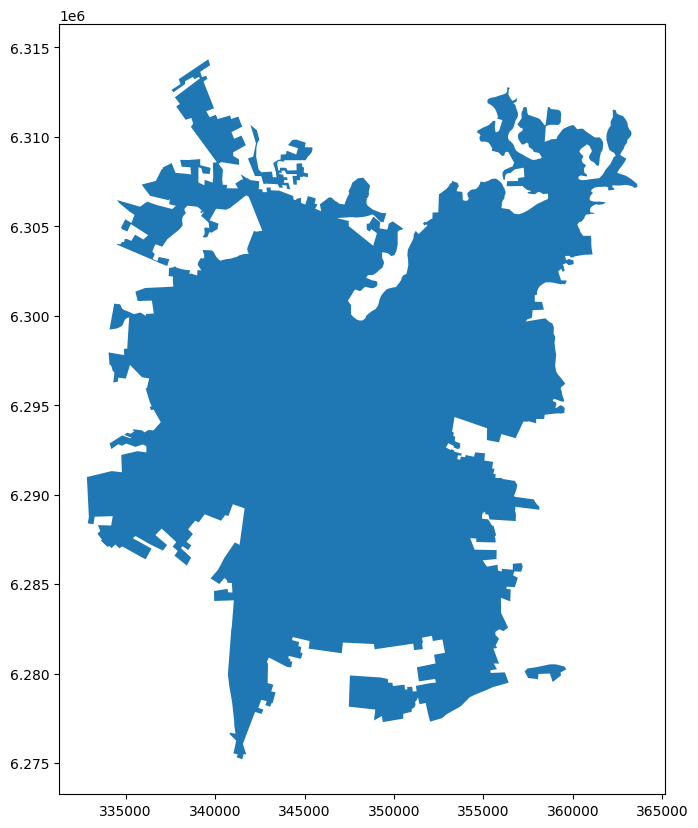

In [98]:
santiago_urbano = areas_urbanas.loc[areas_urbanas['NOMBRE']=='Santiago']
santiago_urbano.plot(figsize = (10,10))

La propiedad `.crs` en un GeoDataFrame se utiliza para consultar o definir el sistema de referencia de coordenadas (CRS) asociado a los datos geoespaciales. El CRS determina cómo se ubican y proyectan las geometrías sobre la superficie terrestre, lo que es esencial para realizar cálculos espaciales precisos, como medir distancias, generar buffers o hacer uniones espaciales.

Es fundamental que todos los conjuntos de datos que se quieran usar conjuntamente en una operación espacial tengan el mismo CRS. Por ello, `.crs` permite verificar la compatibilidad entre capas y, si es necesario, transformarlas para que utilicen el mismo sistema de coordenadas.

In [99]:
distritos.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [100]:
santiago_urbano.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Realizar la intersección espacial entre el área urbana de Santiago y los distritos censales.

<Axes: >

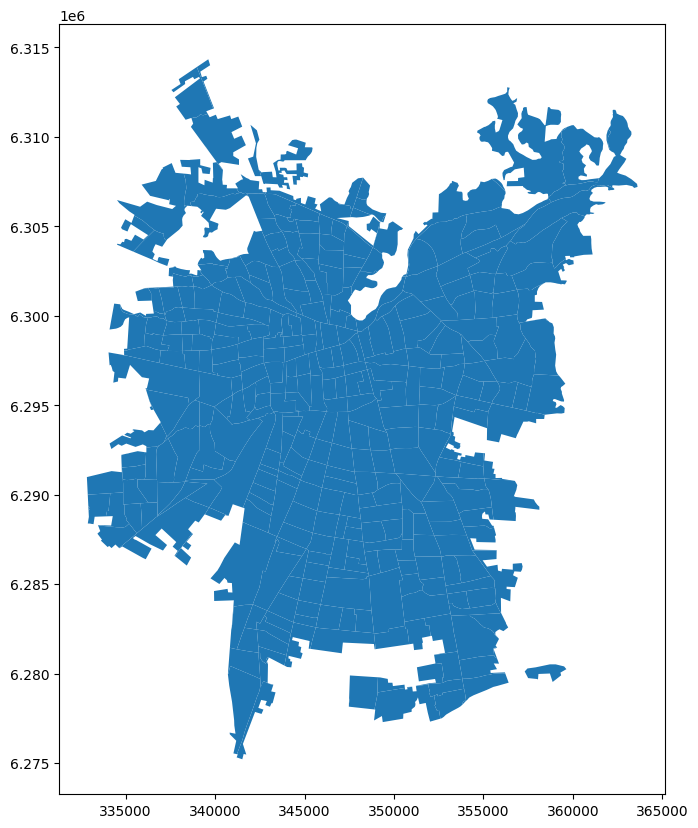

In [101]:
distritos_urbanos = gpd.overlay(santiago_urbano, distritos, how='intersection')
distritos_urbanos.plot(figsize=(10,10))

Definir la métrica.

In [102]:
pesos = {'E': 1, 'D': 2, 'C3': 3, 'C2': 4, 'ABC1': 5}

for col in pesos.keys():
    distritos_urbanos[col] = distritos_urbanos[col].fillna(0)

numerador = sum(pesos[col] * distritos_urbanos[col] for col in pesos)
denominador = distritos_urbanos[list(pesos.keys())].sum(axis=1)

distritos_urbanos['indice_nse'] = numerador / denominador

def clasificar_nse(valor):
    if valor < 2.5:
        return 'Bajo'
    elif valor < 3.5:
        return 'Medio'
    else:
        return 'Alto'

Graficar.

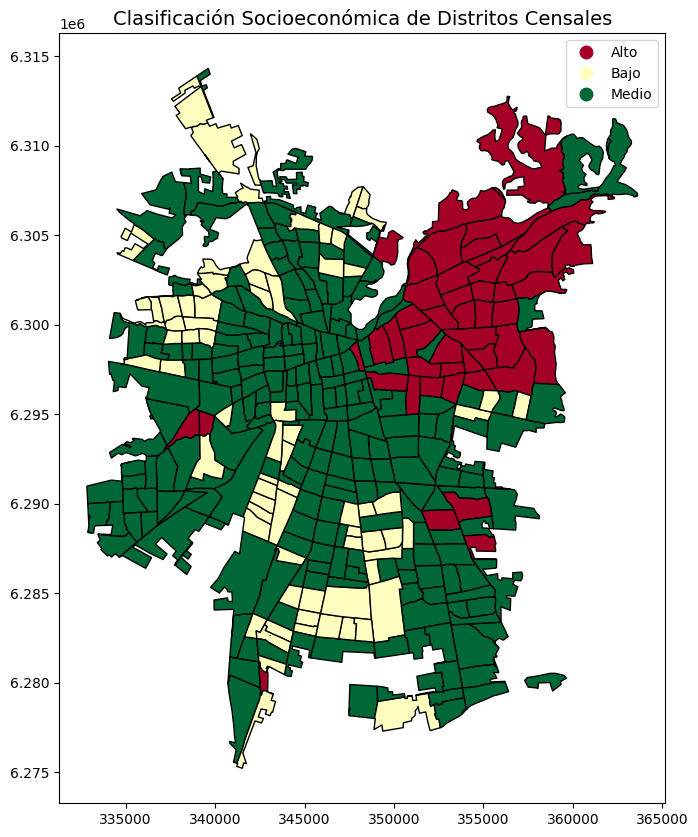

In [103]:
distritos_urbanos['nivel_nse'] = distritos_urbanos['indice_nse'].apply(clasificar_nse)

fig, ax = plt.subplots(figsize=(10, 10))
distritos_urbanos.plot(column='nivel_nse', ax=ax, legend=True, cmap='RdYlGn', edgecolor='black')

ax.set_title("Clasificación Socioeconómica de Distritos Censales", fontsize=14)

plt.show()

### Misión 2

Cargar lineas de metro.

,OBJECTID,ID_LINEA,LINEA,LENGTH,Shape_Leng,Shape_Le_1,geometry
0,3,2,L2,18315.942,20087.016072,1301.975352,"LINESTRING (-70.66142 -33.52651, -70.66325 -33..."
1,4,2,L2,18315.942,20087.016072,1057.384032,"LINESTRING (-70.65881 -33.51723, -70.66138 -33..."
2,5,2,L2,18315.942,20087.016072,802.130950,"LINESTRING (-70.65682 -33.5102, -70.65865 -33...."
3,6,2,L2,18315.942,20087.016072,599.761286,"LINESTRING (-70.65315 -33.49734, -70.65346 -33..."
4,7,2,L2,18315.942,20087.016072,866.182956,"LINESTRING (-70.65465 -33.5026, -70.65679 -33...."
...,...,...,...,...,...,...,...
132,144,6,L6,0.000,15680.851666,15408.273451,"LINESTRING (-70.69536 -33.48342, -70.69189 -33..."
133,148,2,L2,0.000,0.000000,0.000000,"LINESTRING (-70.67355 -33.5714, -70.67585 -33...."
134,145,2,L2,0.000,0.000000,0.000000,"LINESTRING (-70.66432 -33.53736, -70.66627 -33..."
135,146,2,L2,0.000,0.000000,0.000000,"LINESTRING (-70.66667 -33.54632, -70.66791 -33..."


<Axes: >

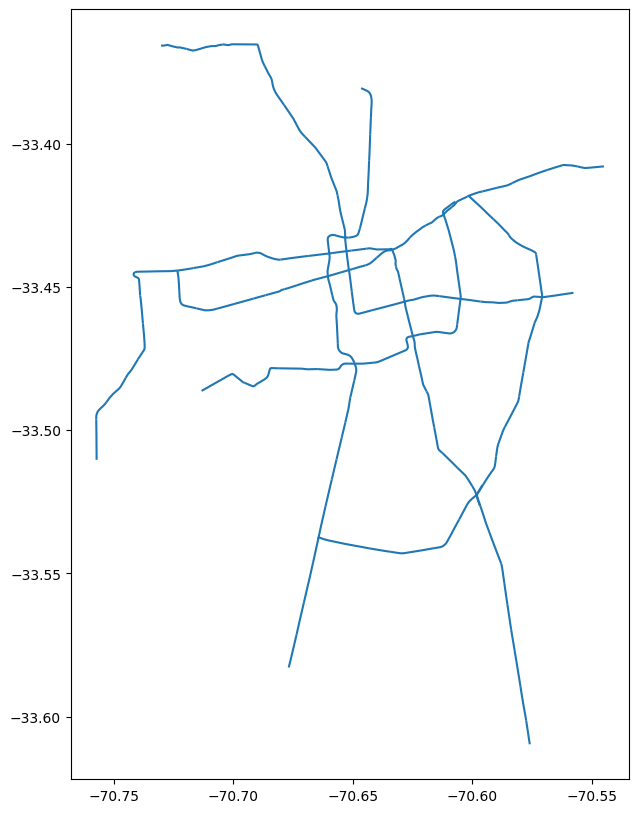

In [104]:
lineas_shp = "Data/Metro 2020/Lineas_2020/Lineas_2020.shp"
lineas_metro = gpd.read_file(lineas_shp)
display(lineas_metro)
lineas_metro.plot(figsize=(10,10))

Verificar CRS

In [105]:
distritos_urbanos.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [106]:
lineas_metro.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [107]:
lineas_metro = lineas_metro.to_crs(distritos_urbanos.crs)
lineas_metro.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Filtrar estaciones de metro solamente en distritos altos.

<Axes: >

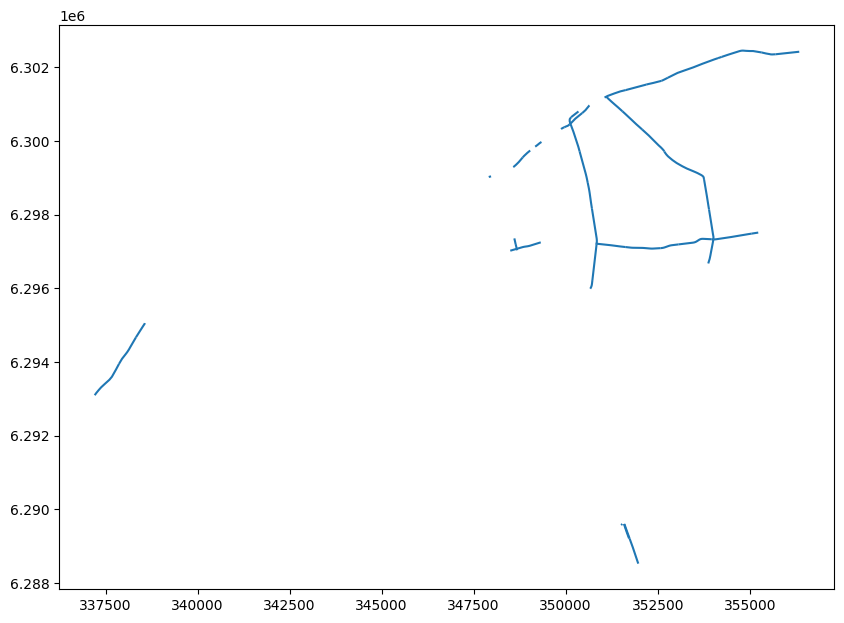

In [108]:
distritos_alto = distritos_urbanos[distritos_urbanos['nivel_nse'] == 'Alto']

lineas_en_alto = gpd.overlay(lineas_metro, distritos_alto, how='intersection')
lineas_en_alto.plot(figsize=(10,10))

Graficar lineas de metro que pasan por distritos de NSE alto.

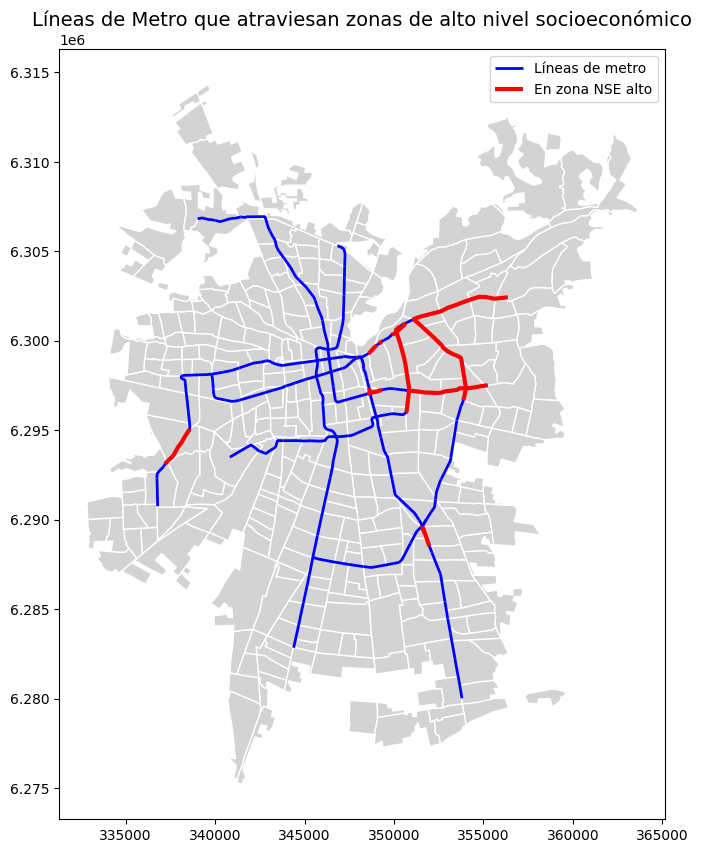

In [109]:
lineas_metro['tipo'] = 'Normal'
lineas_en_alto['tipo'] = 'En zona NSE Alto'

fig, ax = plt.subplots(figsize=(10, 10))

distritos_urbanos.plot(ax=ax, color='lightgrey', edgecolor='white')

lineas_metro.plot(ax=ax, color='blue', linewidth=2, label='Líneas de metro')

lineas_en_alto.plot(ax=ax, color='red', linewidth=3, label='En zona NSE alto')

ax.set_title("Líneas de Metro que atraviesan zonas de alto nivel socioeconómico", fontsize=14)
plt.legend()

plt.show()

### Misión 3

Cargar estaciones de metro.

,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,geometry
0,2,2,L2,EL PARRON,El Parrón,345717.3664,6.289105e+06,POINT (345717.366 6289105.444)
1,3,5,L5,CUMMING,Cumming,344899.1198,6.298782e+06,POINT (344899.12 6298781.571)
2,4,5,L5,QUINTA NORMAL,Quinta Normal,343809.1081,6.298628e+06,POINT (343808.803 6298622.125)
3,5,7,L4A,SAN RAMON,San Ramón,346685.4133,6.287624e+06,POINT (347436.975 6287501.27)
4,6,7,L4A,SANTA ROSA,Santa Rosa,348282.5816,6.287378e+06,POINT (348282.582 6287378.409)
...,...,...,...,...,...,...,...,...
122,128,2,L2,LO ESPEJO,Lo Espejo,0.0000,0.000000e+00,POINT (345264.86 6286901.58)
123,129,2,L2,OBSERVATORIO,Observatorio,0.0000,0.000000e+00,POINT (344934.152 6285352.774)
124,130,2,L2,LO MARTÏNEZ,Lo Martínez,0.0000,0.000000e+00,POINT (344670.554 6284110.212)
125,131,2,L2,HOSPITAL EL PINO,Hospital El Pino,0.0000,0.000000e+00,POINT (344396.214 6282872.929)


<Axes: >

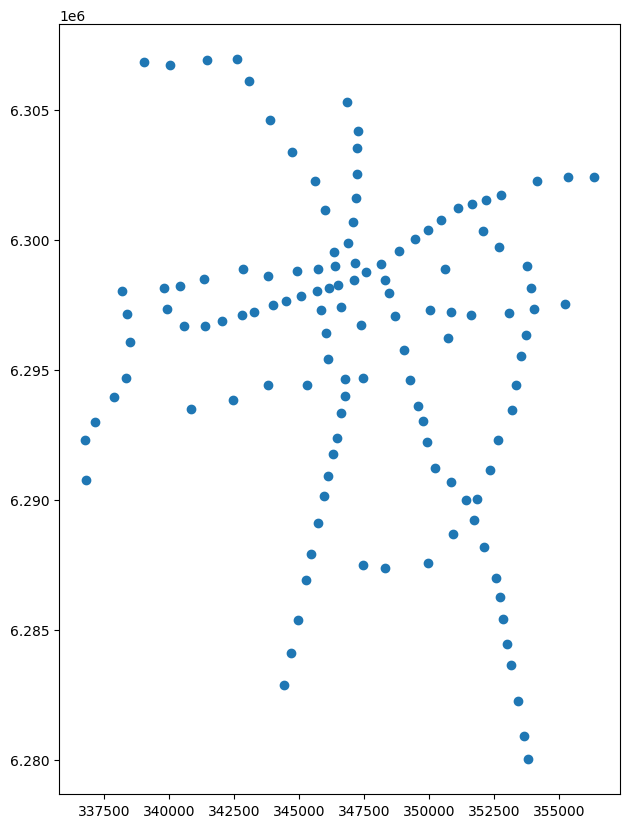

In [110]:
estaciones_shp = 'Data/Metro 2020/Estaciones_2020/Estaciones_2020.shp'
estaciones = gpd.read_file(estaciones_shp)
display(estaciones)
estaciones.plot(figsize=(10,10))

Verificar CRS

In [111]:
estaciones.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [112]:
distritos_urbanos.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Calcular centroide.

In [113]:
distritos_urbanos['centroide'] = distritos_urbanos.geometry.centroid
centros = distritos_urbanos.set_geometry('centroide')
display(centros)

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,...,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,indice_nse,nivel_nse,centroide
0,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,...,1390.0,365.0,3412.0,704315.75,48.44,31.09,"POLYGON ((346788.392 6299461.792, 346943.942 6...",3.488570,Medio,POINT (347255.676 6298958.015)
1,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,...,903.0,228.0,2741.0,1166659.89,23.49,21.10,"POLYGON ((345961.61 6299612.269, 346298.704 62...",3.254287,Medio,POINT (346388.173 6298891.253)
2,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,...,891.0,113.0,2387.0,509080.85,46.89,12.00,"POLYGON ((345650.511 6299703.57, 345809.442 62...",3.273146,Medio,POINT (345804.699 6298808.712)
3,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,...,2202.0,423.0,5062.0,761738.52,66.45,10.25,"POLYGON ((345672.277 6298980.643, 345689.082 6...",3.451798,Medio,POINT (345288.057 6298448.534)
4,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,...,974.0,145.0,2899.0,765782.74,37.86,11.87,"POLYGON ((344041.982 6298246.207, 344940.918 6...",3.183167,Medio,POINT (344391.946 6297945.192)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Nogales,...,911.0,72.0,4630.0,2114725.49,21.89,3.40,"POLYGON ((340825.997 6281439.993, 341160.856 6...",2.764363,Medio,POINT (341669.025 6280655.171)
336,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Tejas de Chena,...,750.0,61.0,5401.0,1771750.98,30.48,3.84,"POLYGON ((340901.38 6282439.427, 340932.1 6282...",2.565451,Medio,POINT (341340.66 6282781.452)
337,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Chena,...,1044.0,124.0,4536.0,34934099.30,1.30,0.68,"MULTIPOLYGON (((341046.208 6284092.881, 339946...",2.898148,Medio,POINT (341423.689 6286158.633)
338,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Estación,...,349.0,19.0,3509.0,894566.54,39.23,2.70,"POLYGON ((343007.242 6280895.568, 343001.004 6...",2.442861,Bajo,POINT (343165.331 6280988.488)


Mostrar centroides en los distritos.

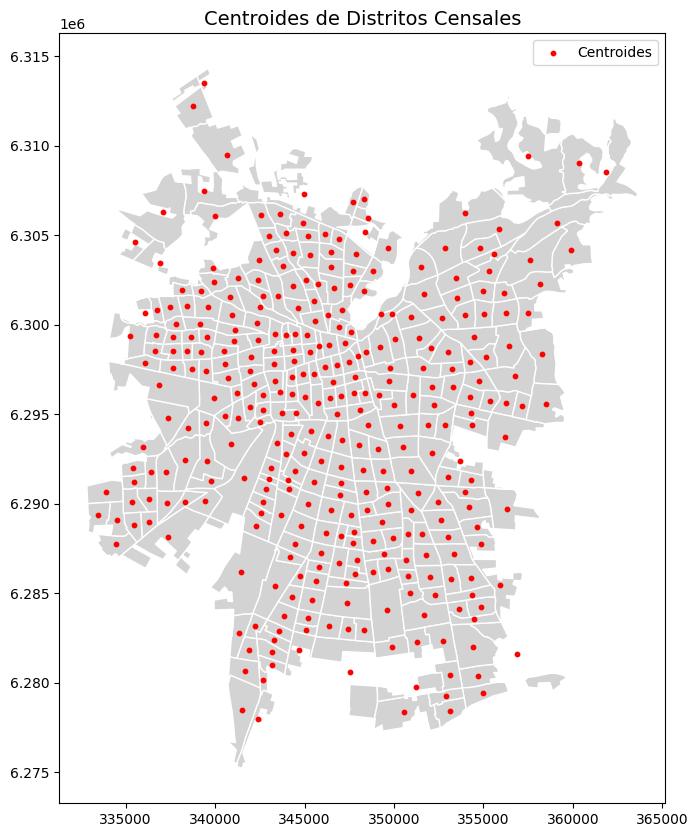

In [123]:
fig, ax = plt.subplots(figsize=(10, 10))

distritos_urbanos.plot(ax=ax, color='lightgrey', edgecolor='white')

centros.plot(ax=ax, color='red', markersize=10, label='Centroides')

ax.set_title("Centroides de Distritos Censales", fontsize=14)
plt.legend()

plt.show()

Crear buffer de 1000 metros alrededor de cada centroide.

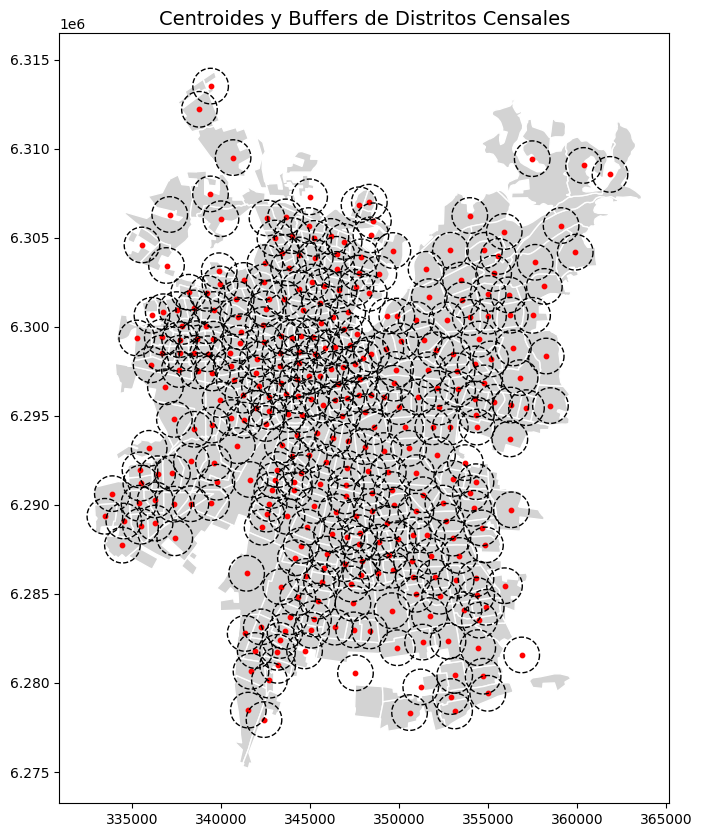

In [132]:
centros['buffer_1000m'] = centros.geometry.buffer(1000)
buffers = centros.set_geometry('buffer_1000m')

fig, ax = plt.subplots(figsize=(10, 10))

distritos_urbanos.plot(ax=ax, color='lightgrey', edgecolor='white')

centros.plot(ax=ax, color='red', markersize=10, label='Centroides')

buffers.plot(ax=ax, color='none', edgecolor='black', label='Buffer de 1000m', linestyle='--')

ax.set_title("Centroides y Buffers de Distritos Censales", fontsize=14)

plt.show()

Contar estaciones por distrito.

In [117]:
estaciones['dentro'] = estaciones.geometry.apply(lambda x: False)

join = gpd.sjoin(estaciones, buffers, predicate='within', how='inner')

conteo = join.groupby('index_right').size()
distritos_urbanos['accesibilidad'] = distritos_urbanos.index.map(conteo).fillna(0).astype(int)

def clasificar_acceso(n):
    if n == 0:
        return 'Sin acceso'
    elif n <= 2:
        return 'Bajo'
    elif n <= 5:
        return 'Medio'
    else:
        return 'Alto'

distritos_urbanos['nivel_acceso'] = distritos_urbanos['accesibilidad'].apply(clasificar_acceso)
display(distritos_urbanos)

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,...,ADIMARK_T,Area,Densidad,1_UF_M2,geometry,indice_nse,nivel_nse,centroide,accesibilidad,nivel_acceso
0,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,...,3412.0,704315.75,48.44,31.09,"POLYGON ((346788.392 6299461.792, 346943.942 6...",3.488570,Medio,POINT (347255.676 6298958.015),6,Alto
1,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,...,2741.0,1166659.89,23.49,21.10,"POLYGON ((345961.61 6299612.269, 346298.704 62...",3.254287,Medio,POINT (346388.173 6298891.253),7,Alto
2,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,...,2387.0,509080.85,46.89,12.00,"POLYGON ((345650.511 6299703.57, 345809.442 62...",3.273146,Medio,POINT (345804.699 6298808.712),7,Alto
3,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,...,5062.0,761738.52,66.45,10.25,"POLYGON ((345672.277 6298980.643, 345689.082 6...",3.451798,Medio,POINT (345288.057 6298448.534),5,Medio
4,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,...,2899.0,765782.74,37.86,11.87,"POLYGON ((344041.982 6298246.207, 344940.918 6...",3.183167,Medio,POINT (344391.946 6297945.192),5,Medio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Nogales,...,4630.0,2114725.49,21.89,3.40,"POLYGON ((340825.997 6281439.993, 341160.856 6...",2.764363,Medio,POINT (341669.025 6280655.171),0,Sin acceso
336,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Tejas de Chena,...,5401.0,1771750.98,30.48,3.84,"POLYGON ((340901.38 6282439.427, 340932.1 6282...",2.565451,Medio,POINT (341340.66 6282781.452),0,Sin acceso
337,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Chena,...,4536.0,34934099.30,1.30,0.68,"MULTIPOLYGON (((341046.208 6284092.881, 339946...",2.898148,Medio,POINT (341423.689 6286158.633),0,Sin acceso
338,Santiago,Ciudad,427491.444262,5.821041e+08,Región Metropolitana De Santiago,134,Maipo,13401,San Bernardo,Estación,...,3509.0,894566.54,39.23,2.70,"POLYGON ((343007.242 6280895.568, 343001.004 6...",2.442861,Bajo,POINT (343165.331 6280988.488),0,Sin acceso


Graficar disitritos con los indices de accesibilidad.

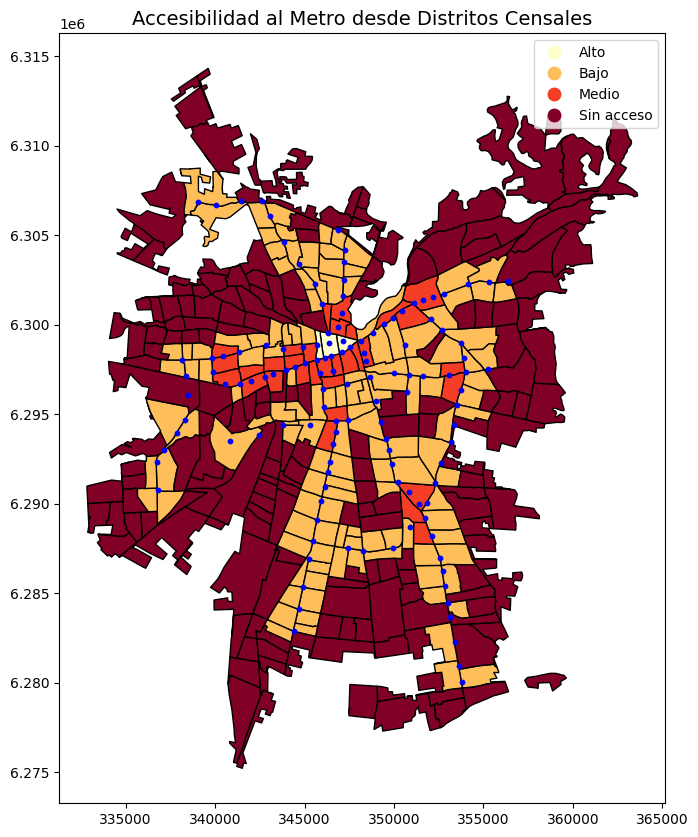

In [121]:
fig, ax = plt.subplots(figsize=(10, 10))

distritos_urbanos.plot(column='nivel_acceso', ax=ax, legend=True, cmap='YlOrRd', edgecolor='black')

estaciones.plot(ax=ax, color='blue', markersize=10, label='Estaciones de metro')

ax.set_title("Accesibilidad al Metro desde Distritos Censales", fontsize=14)
plt.show()